In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
df = pd.read_csv('diabetes.csv')

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

## Train - Test split

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix, \
                            precision_score, recall_score, f1_score, roc_auc_score,roc_curve
from sklearn.svm import SVC

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

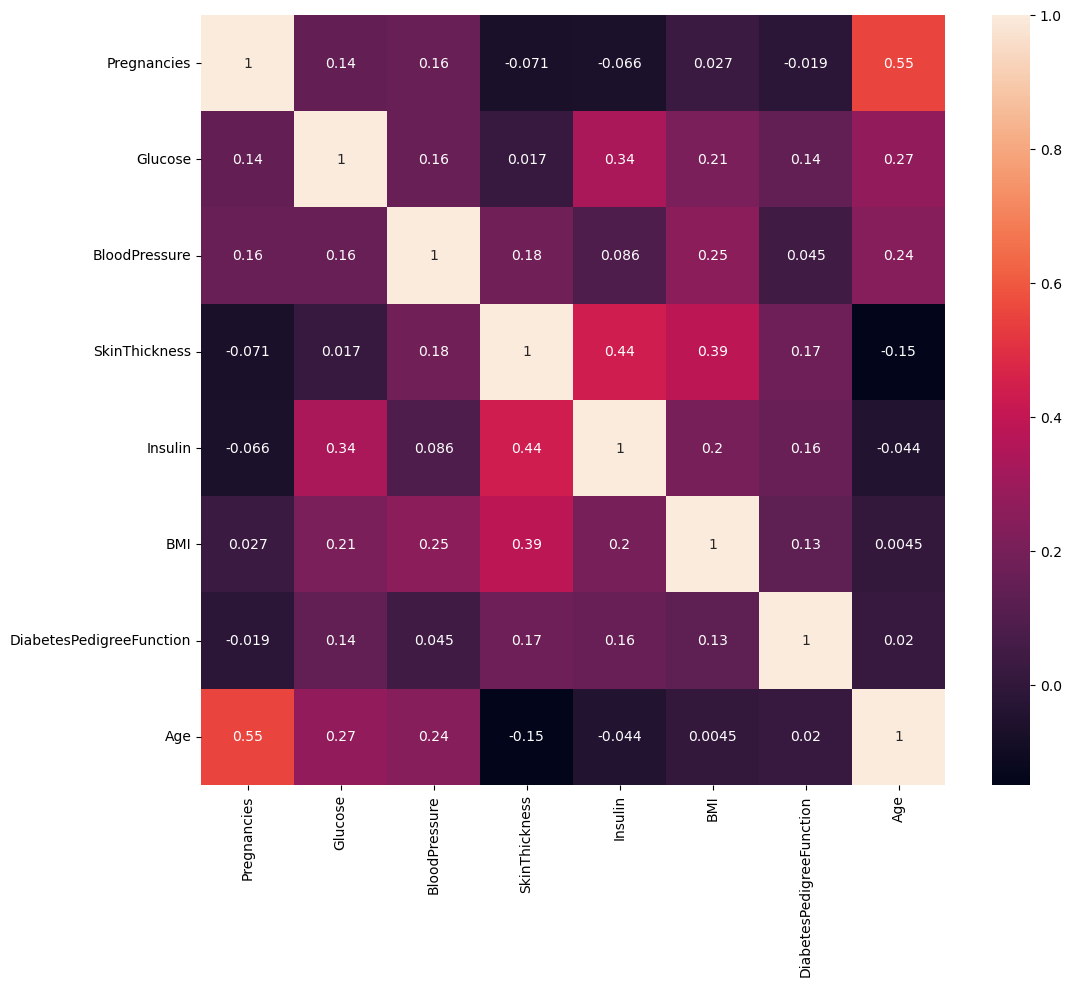

In [6]:
plt.figure(figsize=(12,10))
corr = X_train.corr()
sns.heatmap(corr,annot=True)
plt.show()

## Model Building

In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
models={
    "Logisitic Regression":LogisticRegression(),
    "SVC(Linear)":SVC(kernel='linear'),
    "SVC(rbf)":SVC(kernel='rbf'),
    "SVC(poly)":SVC(kernel='poly'),
    "SVC(sigmoid)":SVC(kernel='sigmoid'),
    "Decision Tree":DecisionTreeClassifier(),
    "Random Forest":RandomForestClassifier(),
    "Gradient Boost":GradientBoostingClassifier(),
    "Adaboost":AdaBoostClassifier(),
    "XgBoost":XGBClassifier()
}
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train_scaled, y_train)

    # Make predictions
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    # Training set performance
    model_train_accuracy = accuracy_score(y_train, y_train_pred) # Calculate Accuracy
    model_train_f1 = f1_score(y_train, y_train_pred, average='weighted') # Calculate F1-score
    model_train_precision = precision_score(y_train, y_train_pred) # Calculate Precision
    model_train_recall = recall_score(y_train, y_train_pred) # Calculate Recall
    model_train_rocauc_score = roc_auc_score(y_train, y_train_pred)


    # Test set performance
    model_test_accuracy = accuracy_score(y_test, y_test_pred) # Calculate Accuracy
    model_test_f1 = f1_score(y_test, y_test_pred, average='weighted') # Calculate F1-score
    model_test_precision = precision_score(y_test, y_test_pred) # Calculate Precision
    model_test_recall = recall_score(y_test, y_test_pred) # Calculate Recall
    model_test_rocauc_score = roc_auc_score(y_test, y_test_pred) #Calculate Roc


    print(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Accuracy: {:.4f}".format(model_train_accuracy))
    print('- F1 score: {:.4f}'.format(model_train_f1))
    
    print('- Precision: {:.4f}'.format(model_train_precision))
    print('- Recall: {:.4f}'.format(model_train_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_train_rocauc_score))

    
    
    print('----------------------------------')
    
    print('Model performance for Test set')
    print('- Accuracy: {:.4f}'.format(model_test_accuracy))
    print('- F1 score: {:.4f}'.format(model_test_f1))
    print('- Precision: {:.4f}'.format(model_test_precision))
    print('- Recall: {:.4f}'.format(model_test_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_test_rocauc_score))
    
    print('----------------------------------')

    print("Confusion matrix")
    print(confusion_matrix(y_test,y_test_pred))
    
    print('----------------------------------')
    print("Classification report")
    print(classification_report(y_test,y_test_pred))

    
    print('='*35)
    print('\n')

Logisitic Regression
Model performance for Training set
- Accuracy: 0.7704
- F1 score: 0.7625
- Precision: 0.7169
- Recall: 0.5587
- Roc Auc Score: 0.7207
----------------------------------
Model performance for Test set
- Accuracy: 0.7532
- F1 score: 0.7542
- Precision: 0.6491
- Recall: 0.6727
- Roc Auc Score: 0.7354
----------------------------------
Confusion matrix
[[79 20]
 [18 37]]
----------------------------------
Classification report
              precision    recall  f1-score   support

           0       0.81      0.80      0.81        99
           1       0.65      0.67      0.66        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154



SVC(Linear)
Model performance for Training set
- Accuracy: 0.7720
- F1 score: 0.7635
- Precision: 0.7239
- Recall: 0.5540
- Roc Auc Score: 0.7209
----------------------------------
Model performance for Test set
- Accuracy:

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


XgBoost
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.7208
- F1 score: 0.7253
- Precision: 0.5909
- Recall: 0.7091
- Roc Auc Score: 0.7182
----------------------------------
Confusion matrix
[[72 27]
 [16 39]]
----------------------------------
Classification report
              precision    recall  f1-score   support

           0       0.82      0.73      0.77        99
           1       0.59      0.71      0.64        55

    accuracy                           0.72       154
   macro avg       0.70      0.72      0.71       154
weighted avg       0.74      0.72      0.73       154





## Hyperparameter tunning on SVC

In [99]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C':[0.1,1,10,100,1000],
    'gamma':[1,0.1,0.01,0.001,0.0001],
    'kernel':['linear']
}

grid_svc = GridSearchCV(SVC(),param_grid=param_grid,cv=5,verbose=3,refit=True)

grid_svc.fit(X_train_scaled,y_train)

grid_svc.best_params_

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV 1/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.756 total time=   0.0s
[CV 2/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.805 total time=   0.0s
[CV 3/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.748 total time=   0.0s
[CV 4/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.748 total time=   0.0s
[CV 5/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.762 total time=   0.0s
[CV 1/5] END ...C=0.1, gamma=0.1, kernel=linear;, score=0.756 total time=   0.0s
[CV 2/5] END ...C=0.1, gamma=0.1, kernel=linear;, score=0.805 total time=   0.0s
[CV 3/5] END ...C=0.1, gamma=0.1, kernel=linear;, score=0.748 total time=   0.0s
[CV 4/5] END ...C=0.1, gamma=0.1, kernel=linear;, score=0.748 total time=   0.0s
[CV 5/5] END ...C=0.1, gamma=0.1, kernel=linear;, score=0.762 total time=   0.0s
[CV 1/5] END ..C=0.1, gamma=0.01, kernel=linear;, score=0.756 total time=   0.0s
[CV 2/5] END ..C=0.1, gamma=0.01, kernel=linear

{'C': 10, 'gamma': 1, 'kernel': 'linear'}

In [100]:
grid_svc.best_score_

0.7638544582167134

In [101]:
y_pred = grid_svc.predict(X_test_scaled)

print(confusion_matrix(y_pred,y_test))
print(accuracy_score(y_pred,y_test))
print(classification_report(y_pred,y_test))

[[81 19]
 [18 36]]
0.7597402597402597
              precision    recall  f1-score   support

           0       0.82      0.81      0.81       100
           1       0.65      0.67      0.66        54

    accuracy                           0.76       154
   macro avg       0.74      0.74      0.74       154
weighted avg       0.76      0.76      0.76       154



## Hyperparameter tunning on Decision Tree

In [66]:
treeclassifier = DecisionTreeClassifier()

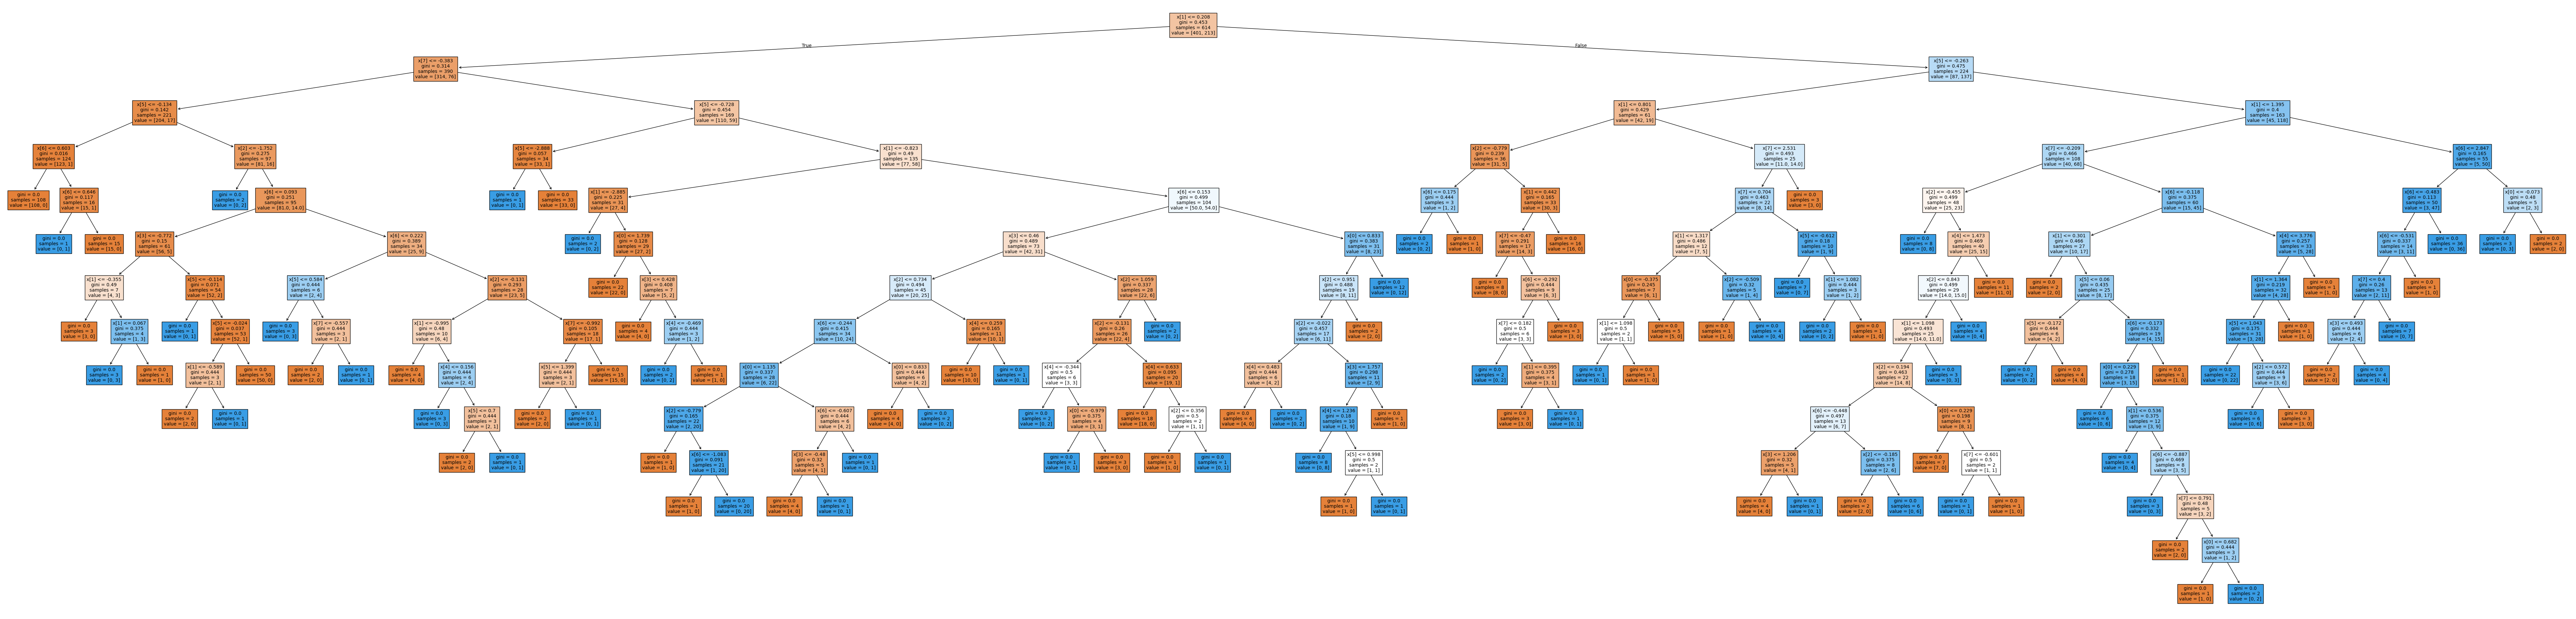

In [68]:
treeclassifier.fit(X_train_scaled,y_train)
from sklearn import tree
plt.figure(figsize=(100,24))
tree.plot_tree(treeclassifier,filled=True)
plt.show()

In [69]:
# Dicision tree hyper parameter tuning

from sklearn.model_selection import GridSearchCV

param = {
    'criterion':['gini', 'entropy','log_loss'],
    'splitter':['best', 'random'],
    'max_depth':[1,2,3,4,5,6,7,8,9,10,11,12],
    'max_features':['auto','sqrt', 'log2']
}

treemodel = DecisionTreeClassifier()
grid_dt = GridSearchCV(treemodel,param_grid=param,cv=5,scoring='accuracy')

import warnings
warnings.filterwarnings('ignore')
grid_dt.fit(X_train_scaled,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'splitter': ['best', 'random']},
             scoring='accuracy')

In [72]:
grid_dt.best_params_

{'criterion': 'entropy',
 'max_depth': 2,
 'max_features': 'log2',
 'splitter': 'best'}

In [74]:
grid_dt.best_score_

0.7524190323870452

In [76]:
y_pred = grid_dt.predict(X_test_scaled)
print(confusion_matrix(y_pred,y_test))
print(accuracy_score(y_pred,y_test))
print(classification_report(y_pred,y_test))

[[77 18]
 [22 37]]
0.7402597402597403
              precision    recall  f1-score   support

           0       0.78      0.81      0.79        95
           1       0.67      0.63      0.65        59

    accuracy                           0.74       154
   macro avg       0.73      0.72      0.72       154
weighted avg       0.74      0.74      0.74       154



## Hyper parameter tuning on Random Forest 

In [79]:
rf_params = {"max_depth": [5, 8, 9, None, 10,11,12],
             "max_features": [5, 7, "auto", 8,12],
             "min_samples_split": [2, 8, 15, 20],
             "n_estimators": [100, 200, 500, 1000]}

In [83]:
grid_rf = GridSearchCV(RandomForestClassifier(),param_grid=rf_params,cv=5,verbose=3,refit=True)

In [85]:
grid_rf.fit(X_train_scaled,y_train)

Fitting 5 folds for each of 560 candidates, totalling 2800 fits
[CV 1/5] END max_depth=5, max_features=5, min_samples_split=2, n_estimators=100;, score=0.780 total time=   0.1s
[CV 2/5] END max_depth=5, max_features=5, min_samples_split=2, n_estimators=100;, score=0.813 total time=   0.1s
[CV 3/5] END max_depth=5, max_features=5, min_samples_split=2, n_estimators=100;, score=0.756 total time=   0.1s
[CV 4/5] END max_depth=5, max_features=5, min_samples_split=2, n_estimators=100;, score=0.724 total time=   0.1s
[CV 5/5] END max_depth=5, max_features=5, min_samples_split=2, n_estimators=100;, score=0.803 total time=   0.1s
[CV 1/5] END max_depth=5, max_features=5, min_samples_split=2, n_estimators=200;, score=0.797 total time=   0.4s
[CV 2/5] END max_depth=5, max_features=5, min_samples_split=2, n_estimators=200;, score=0.813 total time=   0.4s
[CV 3/5] END max_depth=5, max_features=5, min_samples_split=2, n_estimators=200;, score=0.740 total time=   0.4s
[CV 4/5] END max_depth=5, max_fe

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [5, 8, 9, None, 10, 11, 12],
                         'max_features': [5, 7, 'auto', 8, 12],
                         'min_samples_split': [2, 8, 15, 20],
                         'n_estimators': [100, 200, 500, 1000]},
             verbose=3)

In [91]:
grid_rf.best_params_

{'max_depth': 9,
 'max_features': 12,
 'min_samples_split': 8,
 'n_estimators': 200}

In [93]:
grid_rf.best_score_

0.7883113421298147

In [95]:
y_pred = grid_rf.predict(X_test_scaled)
print(confusion_matrix(y_pred,y_test))
print(accuracy_score(y_pred,y_test))
print(classification_report(y_pred,y_test))

[[76 17]
 [23 38]]
0.7402597402597403
              precision    recall  f1-score   support

           0       0.77      0.82      0.79        93
           1       0.69      0.62      0.66        61

    accuracy                           0.74       154
   macro avg       0.73      0.72      0.72       154
weighted avg       0.74      0.74      0.74       154



## Linear SVC

In [112]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV

param_grid = {
    'penalty':['l1','l2'],
    'loss':['hinge', 'squared_hinge'],
    'C':[0.1,1,10,20,30,50,100,1000],
    'max_iter':[100,200,500,1000,2000]
}

grid_lsvc = GridSearchCV(LinearSVC(),param_grid=param_grid,cv=5,verbose=3,refit=True)

grid_lsvc.fit(X_train_scaled,y_train)

grid_lsvc.best_params_

grid_lsvc.best_score_

Fitting 5 folds for each of 160 candidates, totalling 800 fits
[CV 1/5] END C=0.1, loss=hinge, max_iter=100, penalty=l1;, score=nan total time=   0.0s
[CV 2/5] END C=0.1, loss=hinge, max_iter=100, penalty=l1;, score=nan total time=   0.0s
[CV 3/5] END C=0.1, loss=hinge, max_iter=100, penalty=l1;, score=nan total time=   0.0s
[CV 4/5] END C=0.1, loss=hinge, max_iter=100, penalty=l1;, score=nan total time=   0.0s
[CV 5/5] END C=0.1, loss=hinge, max_iter=100, penalty=l1;, score=nan total time=   0.0s
[CV 1/5] END C=0.1, loss=hinge, max_iter=100, penalty=l2;, score=0.756 total time=   0.0s
[CV 2/5] END C=0.1, loss=hinge, max_iter=100, penalty=l2;, score=0.805 total time=   0.0s
[CV 3/5] END C=0.1, loss=hinge, max_iter=100, penalty=l2;, score=0.732 total time=   0.0s
[CV 4/5] END C=0.1, loss=hinge, max_iter=100, penalty=l2;, score=0.740 total time=   0.0s
[CV 5/5] END C=0.1, loss=hinge, max_iter=100, penalty=l2;, score=0.762 total time=   0.0s
[CV 1/5] END C=0.1, loss=hinge, max_iter=200, p

0.773610555777689

In [114]:
grid_lsvc.best_params_

{'C': 20, 'loss': 'hinge', 'max_iter': 1000, 'penalty': 'l2'}

In [116]:
grid_lsvc.best_score_

0.773610555777689

In [118]:
y_pred = grid_lsvc.predict(X_test_scaled)
print(confusion_matrix(y_pred,y_test))
print(accuracy_score(y_pred,y_test))
print(classification_report(y_pred,y_test))

[[81 20]
 [18 35]]
0.7532467532467533
              precision    recall  f1-score   support

           0       0.82      0.80      0.81       101
           1       0.64      0.66      0.65        53

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.76      0.75      0.75       154



## Saving the model

In [124]:
import pickle
pickle.dump(grid_svc.best_estimator_,open('diabetes_model.pkl','wb'))
pickle.dump(scaler,open('diabetes_scaler.pkl','wb'))